# Customer Segmentation Project

## Business Goal

**Problem:** Marketing currently sends the same campaigns to the entire customer base. Response rates are low because a single offer doesn't fit a customer who buys weekly online and a customer who hasn't purchased in months.

**Goal:** Segment customers into a small number of groups the marketing team can target differently — e.g. loyalty/upsell offers for high-value customers, win-back campaigns for inactive customers, and channel-specific promotions for web-heavy vs. store-heavy shoppers. The output should let a marketer look up a customer (existing or new) and get a segment label they can act on, not just a cluster number.

**Who uses this:** the marketing/CRM team, via the Streamlit app (`app/segmentation.py`) or a batch export of segment labels for the CRM.

**Success criteria:**
- Clusters are separable enough to be meaningfully different (silhouette score, not just an elbow-plot bend).
- Cluster sizes are large enough to justify a targeted campaign — no clusters of a handful of customers.
- Each cluster's profile maps to a clear, plain-English description a non-technical stakeholder can read and act on (see `config.CLUSTER_NAMES`).
- Results are reproducible: re-running training on the same data should not silently reshuffle which customers land in which segment (`config.RANDOM_STATE`).

**Out of scope for this notebook:** deciding *what* each segment's campaign should be — that's a marketing decision made from the cluster profile below, not a modeling one.

## Notebook Purpose \& Scope

This notebook is for **exploration and justification only**. All production logic (cleaning, feature engineering, model training) lives in `src/` and is imported here rather than duplicated, so this notebook can never drift out of sync with the pipeline that actually runs in `scripts/train.py` and `app/segmentation.py`.

Import necessary 

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # so `config` and `src` resolve from notebooks/

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import config
from src.data.loader import clean_data, load_raw_data
from src.features.engineer import engineer_features
from src.models.train import (
    cluster_profile,
    evaluate_k_range,
    fit_pipeline,
    save_artifacts,
)


## Data Loading & Cleaning

Cleaning logic (missing-value handling, outlier capping) lives in `src/data/loader.py` — see `clean_data()` for exactly what's applied and why.

In [2]:
df_raw = load_raw_data()
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [3]:
df_raw.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Income is the only column with missing values (~1% of rows). `clean_data()` drops these and logs the count, and also caps the known outliers: implausible birth years (e.g. `Year_Birth=1900`) and the extreme income value (~$666k) that would otherwise skew K-Means, which is sensitive to distance-based outliers.

In [4]:
df = clean_data(df_raw)
print(f"Rows before cleaning: {len(df_raw)}, after: {len(df)}")
df.describe()

Rows before cleaning: 2240, after: 2216


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.872744,52036.662004,0.441787,0.505415,2013-07-10 11:29:27.509025280,49.012635,305.091606,26.356047,166.995939,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
min,0.000000,1936.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,24.000000,2.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,174.500000,8.000000,68.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-31 00:00:00,74.000000,505.000000,33.000000,232.250000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,200000.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3249.376275,11.754796,21749.982931,0.536896,0.544181,NaN,28.948352,337.327920,39.793917,224.283273,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417


## Feature Engineering

`engineer_features()` adds `Age`, `Total_Spending`, `TotalNo_Children`, and `Customer_Tenure`. Defined once in `src/features/engineer.py` and reused by both this notebook and the training pipeline.

In [5]:
df = engineer_features(df)
df[['Age', 'Total_Spending', 'TotalNo_Children', 'Customer_Tenure']].head()

,Age,Total_Spending,TotalNo_Children,Customer_Tenure
0,69,1617,0,5093
1,72,27,2,4543
2,61,776,0,4742
3,42,53,1,4569
4,45,422,1,4591


## Visualisations

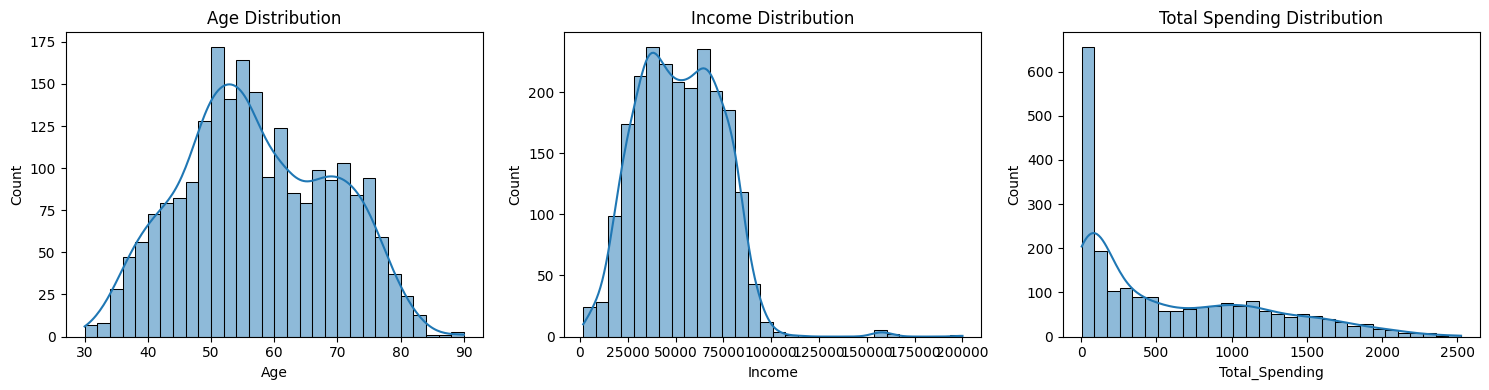

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0]).set_title('Age Distribution')
sns.histplot(df['Income'], bins=30, kde=True, ax=axes[1]).set_title('Income Distribution')
sns.histplot(df['Total_Spending'], bins=30, kde=True, ax=axes[2]).set_title('Total Spending Distribution')
plt.tight_layout()
plt.show()


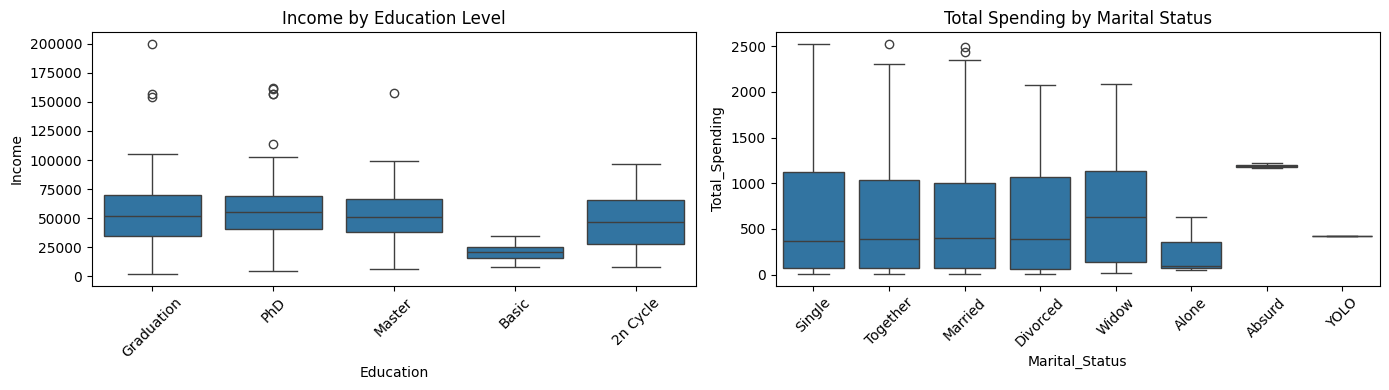

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x="Education", y="Income", data=df, ax=axes[0])
axes[0].set_title("Income by Education Level")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x="Marital_Status", y="Total_Spending", data=df, ax=axes[1])
axes[1].set_title("Total Spending by Marital Status")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


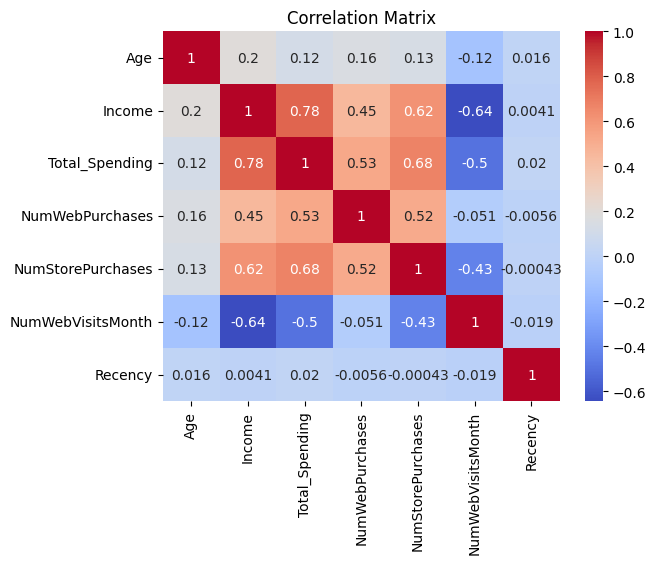

In [8]:
corr = df[config.FEATURES].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


## Choosing K

The elbow method alone is subjective. `evaluate_k_range()` fits a full **scaler -> KMeans pipeline** for each candidate k (not just a bare `KMeans`), so this loop exercises exactly the same code path as final training — and also records the **silhouette score**, which gives a defensible, numeric basis for the final choice rather than eyeballing a bend in a curve.

In [9]:
X = df[config.FEATURES].copy()

# evaluate_k_range takes the RAW feature matrix — each candidate k fits its
# own scaler->KMeans pipeline internally, mirroring final training exactly.
k_results = evaluate_k_range(X)
k_df = pd.DataFrame(k_results).T
k_df


,inertia,silhouette
2,9893.288871,0.327352
3,8659.477097,0.264889
4,7817.376814,0.193060
5,7223.027167,0.188403
6,6724.889976,0.185225
7,6333.989112,0.183410
8,6040.893340,0.182732
9,5792.668567,0.184849


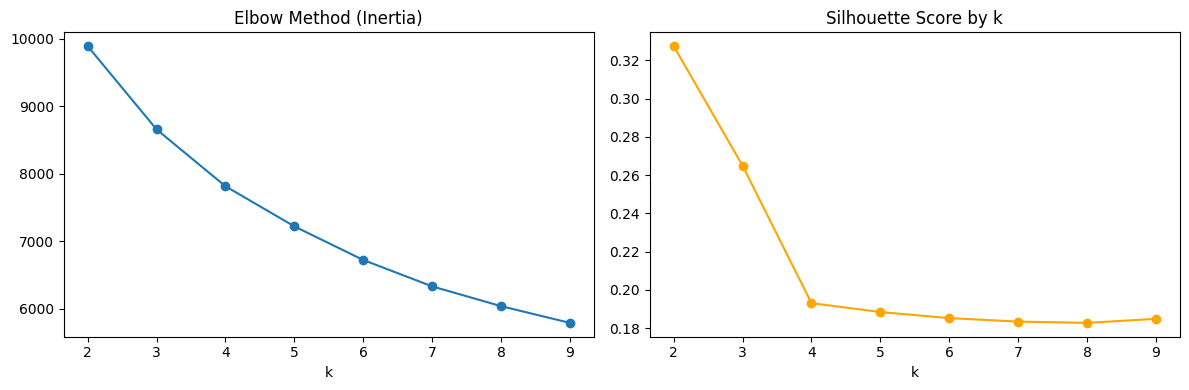

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_df.index, k_df['inertia'], marker='o')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k')

axes[1].plot(k_df.index, k_df['silhouette'], marker='o', color='orange')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()


Both the elbow bend and silhouette score point to **k=5** as a reasonable, interpretable choice for this marketing segmentation use case (`config.N_CLUSTERS = 5`). This matches the value already set in `config.py` — if you land on a different k after reviewing this, update `config.N_CLUSTERS` there rather than hardcoding it elsewhere.

## Fit Final Pipeline

`fit_pipeline()` returns a single `sklearn.pipeline.Pipeline` combining the `StandardScaler` and `KMeans` step as one fitted object — not two separate artifacts. This matters for reproducibility and safety: a pipeline is scaled and clustered in one `.fit()` / `.predict()` call, so there's no way to accidentally pair a model with the wrong scaler (e.g. after retraining one but not the other). `random_state` + `n_init` in `config.py` also make this reproducible — re-running this cell (or `scripts/train.py`) on the same data gives identical cluster assignments every time.

In [11]:
pipeline, labels, silhouette = fit_pipeline(X, n_clusters=config.N_CLUSTERS)
df['Cluster'] = labels
print(f"Silhouette score: {silhouette:.4f}")
df['Cluster'].value_counts().sort_index()


Silhouette score: 0.1884


Cluster
0    531
1    328
2    454
3    562
4    341
Name: count, dtype: int64

## Cluster Profile

This table is what actually determines the cluster *names* — inspect it before writing `config.CLUSTER_NAMES`, don't guess.

In [12]:
profile = cluster_profile(df, labels, extra_cols=['TotalNo_Children'])
profile


,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency,TotalNo_Children
Cluster,,,,,,,,
0,56.438795,36682.350282,133.885122,2.418079,3.478343,6.357815,75.440678,1.288136
1,70.530488,73242.076220,1163.192073,4.557927,8.243902,2.637195,51.429878,0.411585
2,60.550661,58970.759912,857.581498,7.680617,7.859031,6.400881,45.088106,1.052863
3,53.131673,33534.056940,106.332740,2.126335,3.208185,6.620996,25.227758,1.209964
4,47.334311,76811.287390,1300.756598,4.668622,8.601173,2.695015,49.958944,0.357771


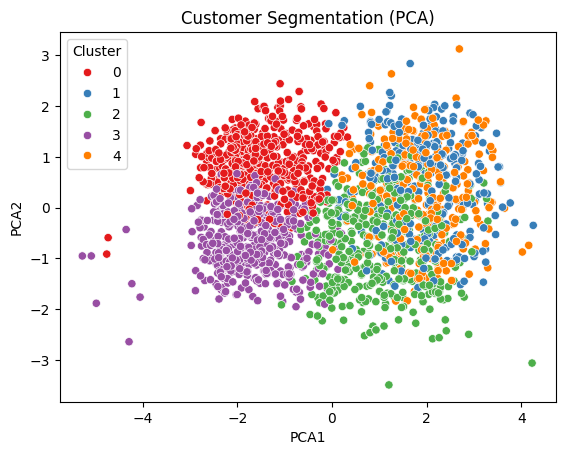

In [13]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(StandardScaler().fit_transform(X))
df['PCA1'], df['PCA2'] = pca_data[:, 0], pca_data[:, 1]

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title('Customer Segmentation (PCA)')
plt.show()


## Cluster Interpretation

Based on `profile` above (matched 1:1 with `config.CLUSTER_NAMES` since k=5 means valid cluster ids are 0–4):

- **Cluster 0** — Low income, low spend, high recency (inactive) -> Low-Engagement / At-Risk Customers
- **Cluster 1** — High income, high spend, older, store-heavy -> Premium Customers (Store-Focused)
- **Cluster 2** — Moderate-high income/spend, high web purchase share -> Digital Buyers
- **Cluster 3** — Low income, low spend, but low recency (recently active) -> Budget Customers (Recently Active)
- **Cluster 4** — Highest income, highest spend -> High-Value Customers

This maps back to the [Business Goal](#Business-Goal) above: Cluster 4 and 1 are prime targets for loyalty/upsell offers, Cluster 0 is the win-back audience, and Cluster 2's web-purchase skew suggests a digital-first promotion channel.

If your `profile` output doesn't match this, update `config.CLUSTER_NAMES` — that's the single source of truth the app reads from.

## Save Artifacts

In practice you'd run this via `python scripts/train.py` (which calls the same `src/pipeline.py` logic), not from the notebook — but shown here for continuity with the exploration above.

In [14]:
metrics = {
    "n_clusters": config.N_CLUSTERS,
    "silhouette_score": silhouette,
    "n_rows_trained": len(df),
    "cluster_sizes": df['Cluster'].value_counts().sort_index().to_dict(),
}
save_artifacts(pipeline, metrics)
metrics


{'n_clusters': 5,
 'silhouette_score': 0.1884033789983527,
 'n_rows_trained': 2216,
 'cluster_sizes': {0: 531, 1: 328, 2: 454, 3: 562, 4: 341}}